<a href="https://colab.research.google.com/github/scaballero1018/tarea-5/blob/main/tarea_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

tarea 5\
¿Se puede predecir el sexo de una persona a partir de variables demográficas y familiares como edad, parentesco, padre y madre?

In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("personas.csv")

print("Primeras filas")
print(df.head())


X = df[['EDAD', 'PARENTESCO', 'PADRE', 'MADRE']]

y = df['SEXO']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


modelo = RandomForestClassifier(random_state=42)

modelo.fit(X_train, y_train)


pred = modelo.predict(X_test)


print("\nExactitud del modelo:")
print(accuracy_score(y_test, pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, pred))

resultados = pd.DataFrame({
    'Valor real': y_test,
    'Predicción': pred
})

print("\nPrimeros resultados")
print(resultados.head(20))

aciertos = (y_test.values == pred).sum()
errores = (y_test.values != pred).sum()

print("\nCantidad de aciertos:", aciertos)
print("Cantidad de errores:", errores)

Primeras filas
   SEXO  EDAD  PARENTESCO  PADRE  MADRE  CONSENTIMIENTO  RESULTADO  \
0     1    59           1      2      2             NaN        NaN   
1     2    56           2      2      2             1.0        1.0   
2     2    28           3      1      1             NaN        NaN   
3     1    25           3      1      1             NaN        NaN   
4     2    62           1      2      2             1.0        1.0   

   DIRECTORIO  SECUENCIA_ENCUESTA  SECUENCIA_P  ORDEN  PER_SELECCIONADA  
0           1                   1            1      1               NaN  
1           1                   2            1      2               1.0  
2           1                   3            1      3               NaN  
3           1                   4            1      4               NaN  
4           2                   1            1      1               1.0  

Exactitud del modelo:
0.597195157956894

Reporte de clasificación:
              precision    recall  f1-score   suppor

el analisis se hara en el word aunque ya podemos ver que el porsetaje de predicion se aproximadamente 59.7% aunque no es demaciado no esta mal y en la cantidad de asiertos vemos como el programa hacerto mas que fallo

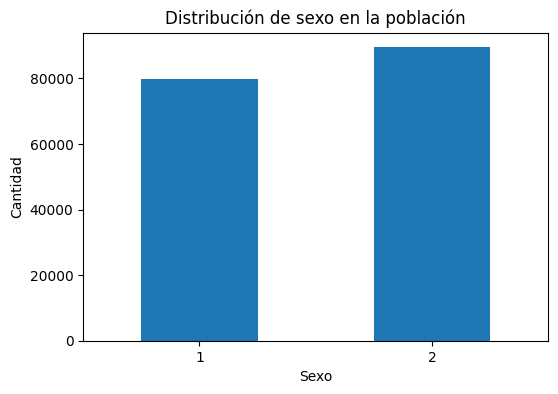

In [9]:
import matplotlib.pyplot as plt

conteo = df['SEXO'].value_counts().sort_index()

plt.figure(figsize=(6,4))

conteo.plot(kind='bar')

plt.title("Distribución de sexo en la población")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")

plt.xticks([0,1], ['1', '2'], rotation=0)

plt.show()

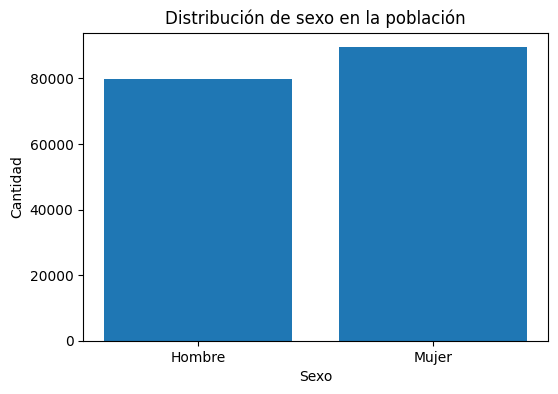

In [11]:
import matplotlib.pyplot as plt

conteo = df['SEXO'].value_counts().sort_index()

nombres = ['Hombre', 'Mujer']

plt.figure(figsize=(6,4))

plt.bar(nombres, conteo)

plt.title("Distribución de sexo en la población")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")

plt.show()